Guided Practice: Implementing Gaussian Mixture Models (GMM) From Scratch

Welcome to the practice notebook. In this assignment, you will implement the Gaussian Mixture Model (GMM) using the Expectation-Maximization (E-M) algorithm. 

Unlike K-Means, GMM provides soft clustering and can model elliptical cluster shapes. We will generate a dataset with stretched, non-spherical clusters to demonstrate the power of GMM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.stats import multivariate_normal
import torch

# Device configuration for future deep learning integrations
device = ('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Configured device: {device}")

Configured device: cpu


Step 1: Generating Synthetic Data

We will generate a 2D dataset with 3 clusters and apply a linear transformation to stretch them into elliptical shapes. This mimics real-world scenarios where features have non-zero covariance.

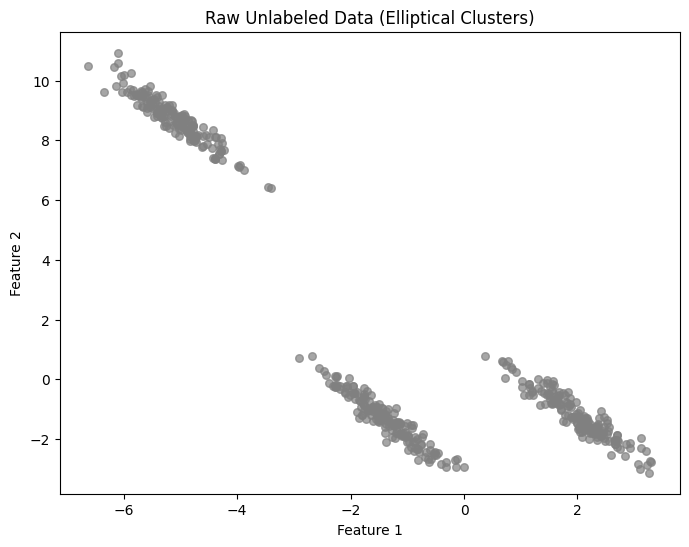

In [2]:
# Generate isotropic Gaussian blobs
X_raw, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=42)

# Apply a transformation to make the clusters elliptical
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X = np.dot(X_raw, transformation)

# Plot the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray', alpha=0.7)
plt.title("Raw Unlabeled Data (Elliptical Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Step 2: Initialize Parameters

A GMM requires three parameters for each cluster k:
1. Mixing weights (pi): The prior probability of each cluster.
2. Means (mu): The center of each cluster.
3. Covariance matrices (sigma): The shape and orientation of each cluster.

Complete the function below to initialize these parameters.

In [3]:
def initialize_parameters(X, k):
    """
    Initialize GMM parameters.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    k : int, number of Gaussian components
    
    Returns:
    pi : array of shape (k,), initial mixing weights (should sum to 1)
    mu : array of shape (k, n_features), initial means
    sigma : array of shape (k, n_features, n_features), initial covariance matrices
    """
    n_samples, n_features = X.shape

    # Initialize mixing weights uniformly
    pi = np.ones(k) / k

    # Initialize means by randomly selecting k data points from X
    rng = np.random.default_rng()
    indices = rng.choice(n_samples, size=k, replace=False)
    mu = X[indices].astype(float)

    # Initialize covariance matrices as the data covariance (regularized) for each cluster
    base_cov = np.cov(X, rowvar=False)
    sigma = np.array([base_cov + 1e-6 * np.eye(n_features) for _ in range(k)])

    return pi, mu, sigma

Step 3: The Expectation Step (E-Step)

In this step, we calculate the "soft responsibilities". For each data point, we compute the probability that it belongs to each of the k clusters, given the current parameters (Bayes' theorem).

Hint: You can use `multivariate_normal(mean, cov).pdf(X)` to calculate the Gaussian likelihoods.

In [4]:
def e_step(X, pi, mu, sigma):
    """
    Perform the Expectation step.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    pi : array of shape (k,)
    mu : array of shape (k, n_features)
    sigma : array of shape (k, n_features, n_features)
    
    Returns:
    responsibilities : array of shape (n_samples, k)
    """
    n_samples = X.shape[0]
    k = len(pi)
    responsibilities = np.zeros((n_samples, k))

    # Calculate the unnormalized likelihoods: pi_k * N(x|mu_k, sigma_k)
    for j in range(k):
        rv = multivariate_normal(mean=mu[j], cov=sigma[j], allow_singular=True)
        responsibilities[:, j] = pi[j] * rv.pdf(X)

    # Normalize the responsibilities so each row sums to 1
    row_sums = responsibilities.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-12
    responsibilities /= row_sums

    return responsibilities

Step 4: The Maximization Step (M-Step)

Now, use the calculated responsibilities to update the parameters (pi, mu, sigma) for each cluster to maximize the likelihood of the data.

In [5]:
def m_step(X, responsibilities):
    """
    Perform the Maximization step.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    responsibilities : array of shape (n_samples, k)
    
    Returns:
    pi : updated mixing weights
    mu : updated means
    sigma : updated covariance matrices
    """
    n_samples, n_features = X.shape
    k = responsibilities.shape[1]

    # Calculate the effective number of points assigned to each cluster (N_k)
    N_k = responsibilities.sum(axis=0)

    # Update the mixing coefficients (pi)
    pi = N_k / n_samples

    # Update the means (mu)
    mu = np.zeros((k, n_features))
    for j in range(k):
        if N_k[j] > 0:
            mu[j] = (responsibilities[:, j][:, None] * X).sum(axis=0) / N_k[j]
        else:
            mu[j] = X[np.random.choice(n_samples)]

    # Update the covariance matrices (sigma)
    sigma = np.zeros((k, n_features, n_features))
    for j in range(k):
        diff = X - mu[j]
        weighted = diff.T * responsibilities[:, j]
        sigma_j = (weighted @ diff) / (N_k[j] if N_k[j] > 0 else 1.0)
        sigma[j] = sigma_j + 1e-6 * np.eye(n_features)

    return pi, mu, sigma

Step 5: Log-Likelihood and the Complete E-M Algorithm

To check for convergence, we monitor the log-likelihood of the data. If the log-likelihood stops increasing significantly, the algorithm has converged.

In [6]:
def compute_log_likelihood(X, pi, mu, sigma):
    """
    Compute the log-likelihood of the dataset given the current GMM parameters.
    """
    n_samples = X.shape[0]
    k = len(pi)
    weighted = np.zeros((n_samples, k))

    for j in range(k):
        rv = multivariate_normal(mean=mu[j], cov=sigma[j], allow_singular=True)
        weighted[:, j] = pi[j] * rv.pdf(X)

    total = weighted.sum(axis=1)
    total[total == 0] = 1e-12
    log_likelihood = np.sum(np.log(total))
    return log_likelihood

def gmm_em(X, k, max_iters=100, tol=1e-4):
    """
    Full GMM Expectation-Maximization algorithm.
    """
    # 1. Initialize parameters
    pi, mu, sigma = initialize_parameters(X, k)
    log_likelihoods = []

    for iteration in range(max_iters):
        # 2. E-Step
        responsibilities = e_step(X, pi, mu, sigma)

        # 3. M-Step
        pi, mu, sigma = m_step(X, responsibilities)

        # 4. Compute Log-Likelihood and check convergence
        ll = compute_log_likelihood(X, pi, mu, sigma)
        log_likelihoods.append(ll)

        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return pi, mu, sigma, responsibilities, log_likelihoods

Step 6: Execution and Visualization

Uncomment the code below to run your GMM implementation. We will convert the soft assignments (responsibilities) into hard cluster assignments using `argmax` to visualize the final groupings.

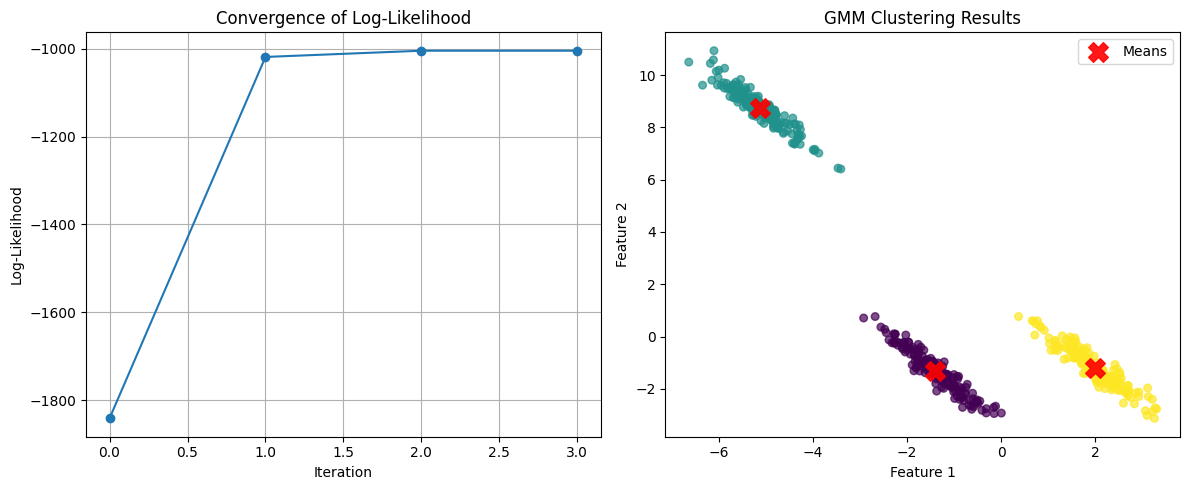

In [7]:
# Set number of components (clusters)
k = 3

# Run the implemented algorithm
final_pi, final_mu, final_sigma, final_resp, log_liks = gmm_em(X, k)

# Convert soft assignments to hard assignments for visualization
cluster_assignments = np.argmax(final_resp, axis=1)

# Plotting the final clustering results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(log_liks, marker='o')
plt.title("Convergence of Log-Likelihood")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=cluster_assignments, s=30, cmap='viridis', alpha=0.7)
plt.scatter(final_mu[:, 0], final_mu[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Means')
plt.title("GMM Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()